In [21]:
import numpy as np
from module.circacompare.compare import circa_single
from module.circacompare.plot import circa_single_plot
from module.circacompare.generator import generate_data


[ 1.02726673 10.16285236  5.59221099]
([array([ 1.11952117, 10.29319854,  5.6050606 ])], [array([ 0.93501229, 10.03250618,  5.57936138])])


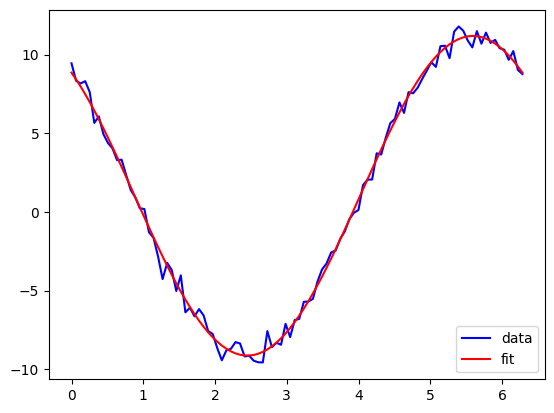

In [ ]:
time = np.linspace(0, 2 * np.pi, 100)   # time is given in radian hours 
measure = generate_data(t=time, k=1, a=10, p=4, noise=0.5)

result = circa_single(t0=time, y0=measure)
print(result.x)                         # result.x contains the estimates for the mesor, amplitude, and phase of the rhythm
print(result.confidence_intervals)      # result.confidence_intervals contains the confidence intervals for the above estimates

circa_single_plot(t0=time, y0=measure)

In [4]:
result

              message: Both `ftol` and `xtol` termination conditions are satisfied.
              success: True
               status: 4
                  fun: [-5.910e-01  9.418e-02 ...  2.232e-01  9.000e-02]
                    x: [ 1.027e+00  1.016e+01  5.592e+00]
                 cost: 10.853567355001163
                  jac: [[ 1.000e+00  7.706e-01  6.477e+00]
                        [ 1.000e+00  7.287e-01  6.960e+00]
                        ...
                        [ 1.000e+00  8.095e-01  5.967e+00]
                        [ 1.000e+00  7.706e-01  6.477e+00]]
                 grad: [ 7.615e-08  2.074e-08  1.989e-08]
           optimality: 7.61532590320968e-08
          active_mask: [ 0.000e+00  0.000e+00  0.000e+00]
                 nfev: 11
                 njev: 10
 confidence_intervals: ([array([ 1.120e+00,  1.029e+01,  5.605e+00])], [array([ 9.350e-01,  1.003e+01,  5.579e+00])])

In [13]:
import pandas as pd
df = pd.read_csv('data/test_circascore.csv')

In [70]:
from module.circacompare.compare import circacompare
from module.circacompare.plot import circacompare_plot

# time = np.linspace(0, 2 * np.pi, 100)
# measure = np.concatenate(
#     (generate_data(t=time, k=1, a=10, p=4, noise=0.4), generate_data(t=time, k=5, a=3, p=1, noise=0.2)))
# group = np.concatenate((np.zeros(len(time)), np.ones(len(time))))
# time = np.concatenate((time, time))

result = circacompare(t0=df['time'], y0=df['count'], g0=df['group'])

print(result.x)                     # has estimates for all parameters
print(result.confidence_intervals)  # has confidence intervals for all parameters

circacompare_plot(t0=df['time'], y0=df['count'], g0=df['group'])

NameError: name 'df' is not defined

In [7]:
result

              message: Both `ftol` and `xtol` termination conditions are satisfied.
              success: True
               status: 4
                  fun: [-4.728e-01  7.534e-02 ...  8.929e-02  3.600e-02]
                    x: [ 1.022e+00  3.989e+00  1.013e+01 -7.205e+00
                         5.588e+00 -3.044e+00]
                 cost: 8.682853884000933
                  jac: [[ 1.000e+00  0.000e+00 ...  6.489e+00 -0.000e+00]
                        [ 1.000e+00  0.000e+00 ...  6.969e+00 -0.000e+00]
                        ...
                        [ 1.000e+00  1.000e+00 ... -1.488e+00 -1.488e+00]
                        [ 1.000e+00  1.000e+00 ... -1.645e+00 -1.645e+00]]
                 grad: [ 6.635e-09  1.088e-14 -2.209e-08  5.856e-10
                         7.416e-08 -1.789e-08]
           optimality: 7.41571835050081e-08
          active_mask: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00
                         0.000e+00  0.000e+00]
                 nfev: 14
         

In [16]:
import pandas as pd
data = pd.read_parquet(r'G:\5k/processed/circa-SD_norm_combined.parquet', columns=['Per2','ZT',"run",'cell_id','cell_type_final'], filters = [("cell_type_final","==","SCH Gaba")])

In [20]:
data.sample(2)

,Per2,ZT,run,cell_id,cell_type_final
SD1-ZT17_fmjnajda-1,0.0,ZT17,SD1,SD1-ZT17_fmjnajda-1,SCH Gaba
circa4-IGM-ZT01_edccoonb-1,0.0,ZT01,circa4,circa4-IGM-ZT01_edccoonb-1,SCH Gaba


In [26]:
timdict= {"ZT01" : 1,
            'ZT05' : 5,
            'ZT09' : 9,
            "ZT13" : 13,
            "ZT17" : 17,
            "ZT21" : 21}

data['time'] = data['ZT'].map(timdict)
data.sort_values(by='time', inplace = True)

In [39]:
time = data['time'].unique()
gene_count = data.groupby('run', "ZT")['Per2'].mean()


result = circa_single(t0=time, y0= gene_count)
print(result.x)                         # result.x contains the estimates for the mesor, amplitude, and phase of the rhythm
print(result.confidence_intervals)      # result.confidence_intervals contains the confidence intervals for the above estimates

circa_single_plot(t0=time, y0=gene_count)

ValueError: No axis named ZT for object type DataFrame

In [85]:
data2 = pd.DataFrame(data=gene_count)

In [86]:
data2['index'] = data2.index
data2

Per2           index
run    ZT                            
SD1    ZT01  0.120381     (SD1, ZT01)
       ZT05  0.198940     (SD1, ZT05)
       ZT09  0.373555     (SD1, ZT09)
       ZT13  0.038749     (SD1, ZT13)
       ZT17  0.081421     (SD1, ZT17)
       ZT21  0.293288     (SD1, ZT21)
circa4 ZT01  0.117780  (circa4, ZT01)
       ZT05  0.240311  (circa4, ZT05)
       ZT09  0.412543  (circa4, ZT09)
       ZT13  0.249799  (circa4, ZT13)
       ZT17  0.094032  (circa4, ZT17)
       ZT21  0.028210  (circa4, ZT21)

In [87]:
data2['group'] = [x[0] for x in data2['index']]
data2['time'] = [x[1] for x in data2['index']]
data2['time'] = data2['time'].map(timdict)
data2['time'] = data2['time'].astype(int)
data2['Per2'] = data2['Per2'] * 100

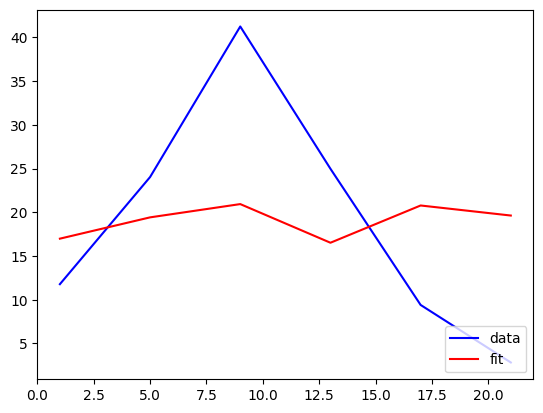

In [88]:
data2.sort_values(by="time",inplace=True)
circa_single(data2[data2['group']=='circa4']['time'], data2[data2['group']=='circa4']['Per2'])
circa_single_plot(data2[data2['group']=='circa4']['time'], data2[data2['group']=='circa4']['Per2'])

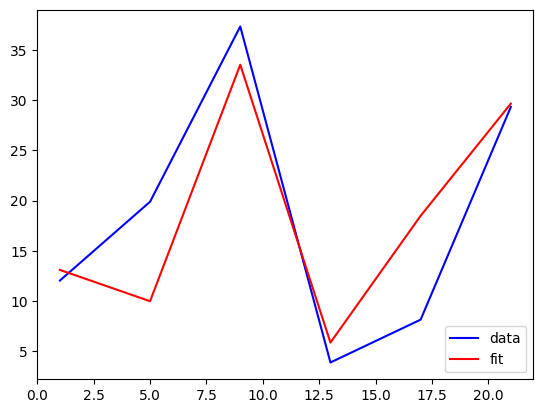

In [89]:
data2.sort_values(by="time",inplace=True)
circa_single(data2[data2['group']=='SD1']['time'], data2[data2['group']=='SD1']['Per2'])
circa_single_plot(data2[data2['group']=='SD1']['time'], data2[data2['group']=='SD1']['Per2'])